In [2]:
from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_split_angle_metrics(csv_path: str, ts_column: str = "ts_total", ts=0) -> None:
    df = pd.read_csv(csv_path)

    required_columns = {
        "split_angle_deg",
        "delta_aic",
        ts_column,
        "ts_half1",
        "ts_half2",
    }
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}. "
            f"Available columns: {list(df.columns)}"
        )

    df = df.sort_values("split_angle_deg")

    fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

    xticks = np.arange(-90, 91, 15)

    for ax in axes:
        ax.set_xticks(xticks)
        ax.tick_params(axis="x", labelbottom=True)

    axes[0].plot(df["split_angle_deg"], df["delta_aic"], marker="o")
    axes[0].set_ylabel("Delta AIC")
    axes[0].set_title("Delta AIC vs. Split Angle")
    axes[0].grid(True)

    axes[1].plot(df["split_angle_deg"], df[ts_column], marker="o", label=ts_column)
    axes[1].axhline(y=ts, linestyle="--", linewidth=1, label="Full disc TS")
    axes[1].legend()
    axes[1].set_ylabel(ts_column)
    axes[1].set_title(f"{ts_column} vs. Split Angle")
    axes[1].grid(True)

    axes[2].plot(df["split_angle_deg"], df["ts_half1"], marker="o", label="ts_half1")
    axes[2].plot(df["split_angle_deg"], df["ts_half2"], marker="o", label="ts_half2")
    axes[2].set_xlabel("Split angle [deg]")
    axes[2].set_ylabel("Half-disc TS")
    axes[2].set_title("Half-disc TS vs. Split Angle")
    axes[2].legend()
    axes[2].grid(alpha=0.5)

    plt.tight_layout()
    plt.show()


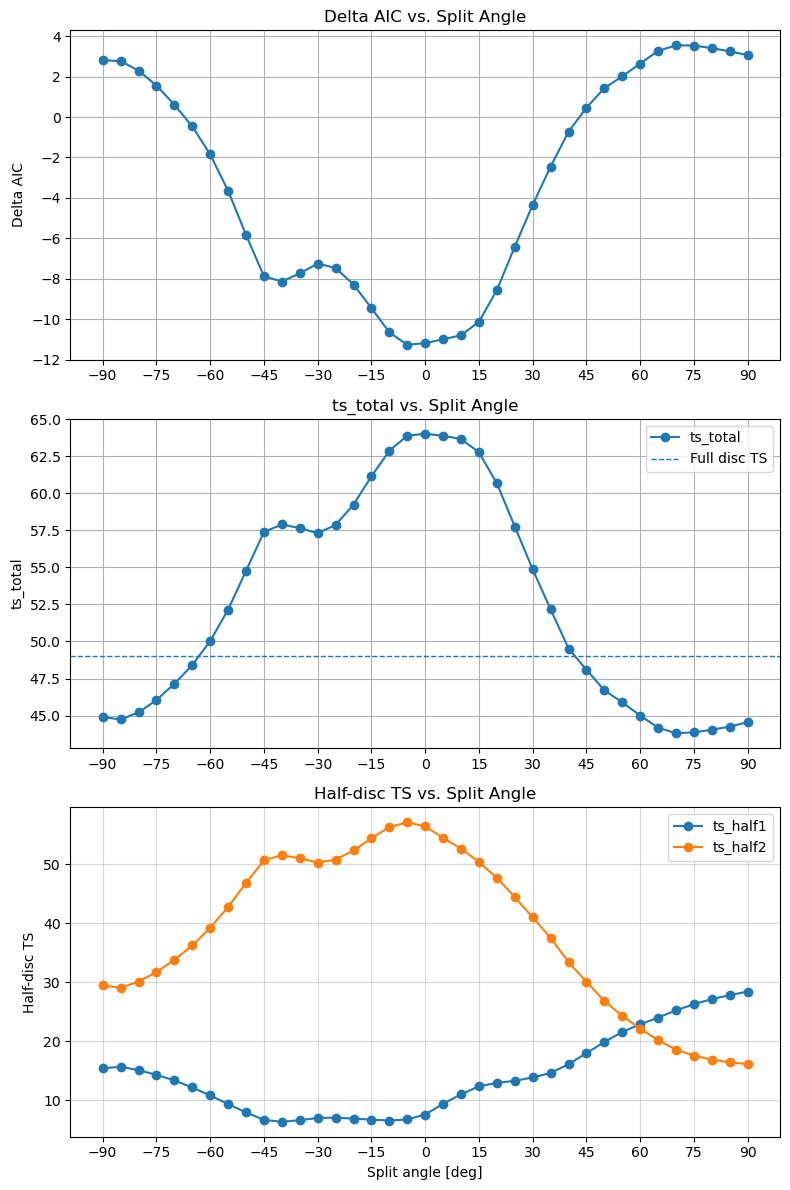

In [3]:
plot_split_angle_metrics("/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/vlad_notebooks/Fermi_5_500GeV/scan_split_angle_results.csv", ts = 49)

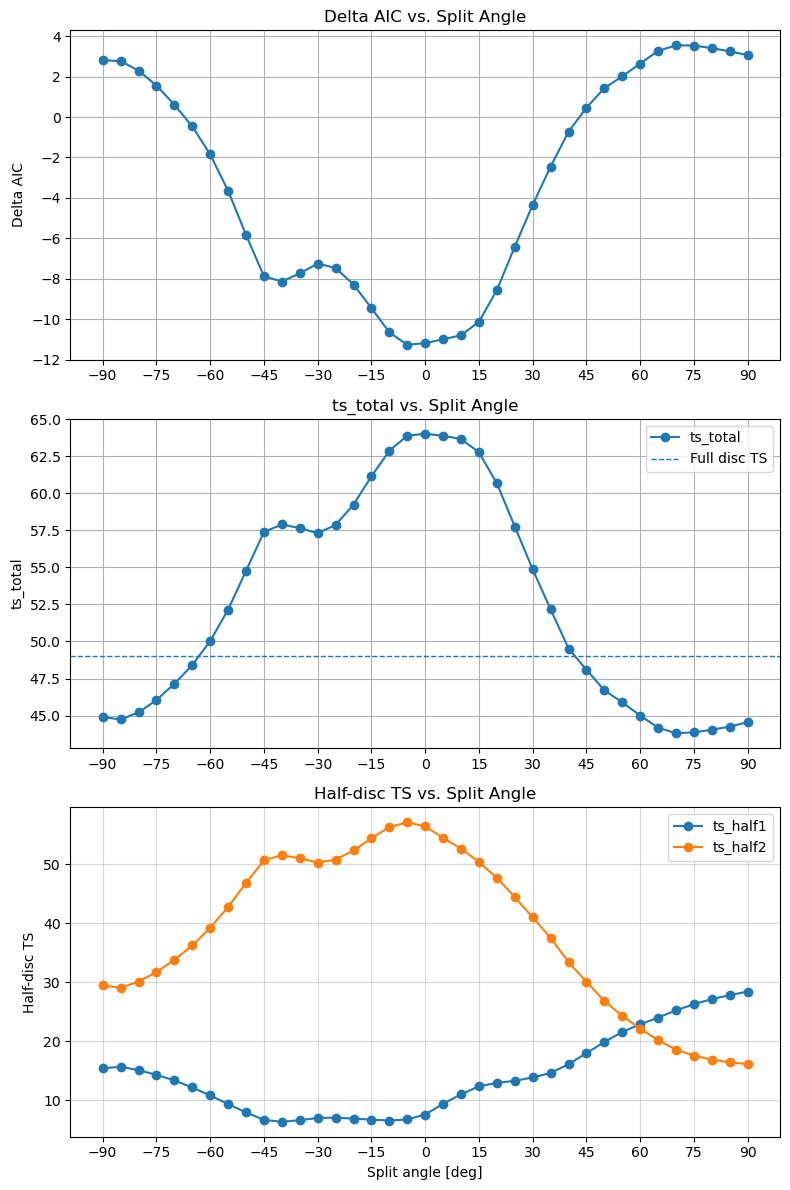

In [14]:
plot_split_angle_metrics("/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/vlad_notebooks/Fermi_5_500GeV/scan_split_angle_results.csv", ts = 49)

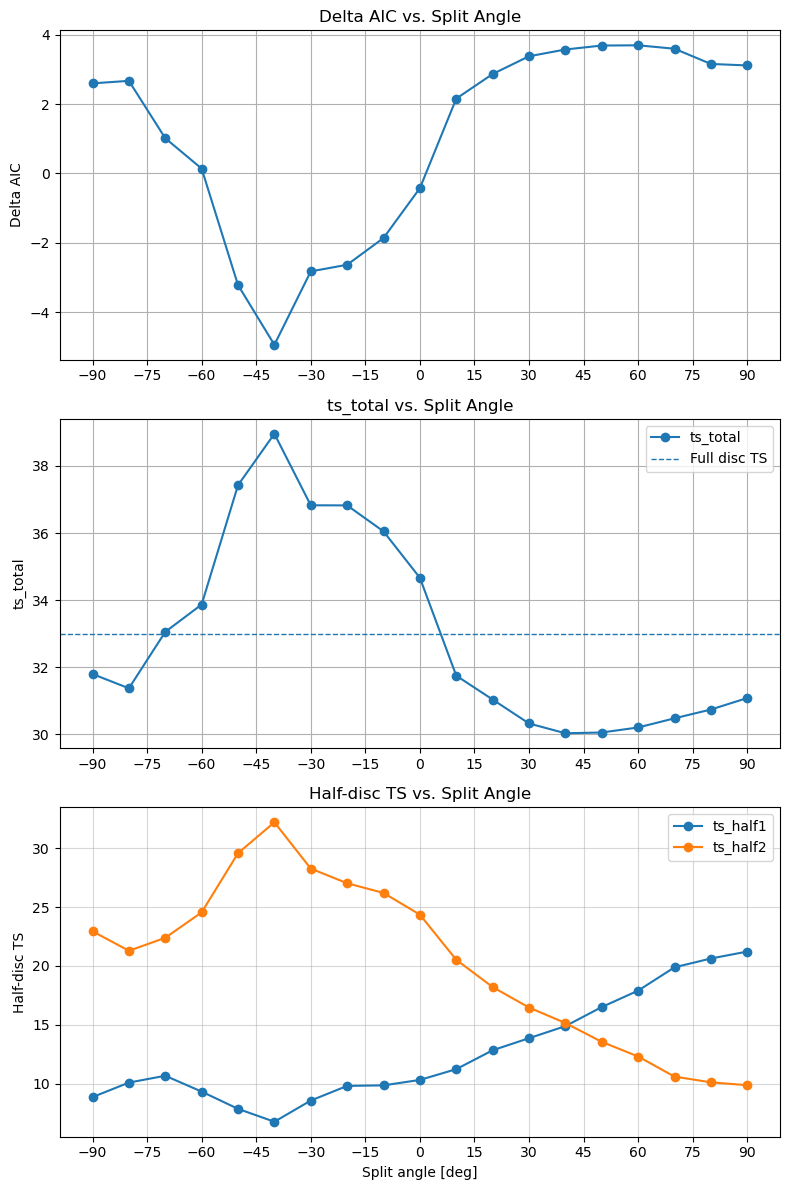

In [15]:
plot_split_angle_metrics("/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/vlad_notebooks/Fermi_10_500GeV/scan_split_angle_results.csv", ts = 33)

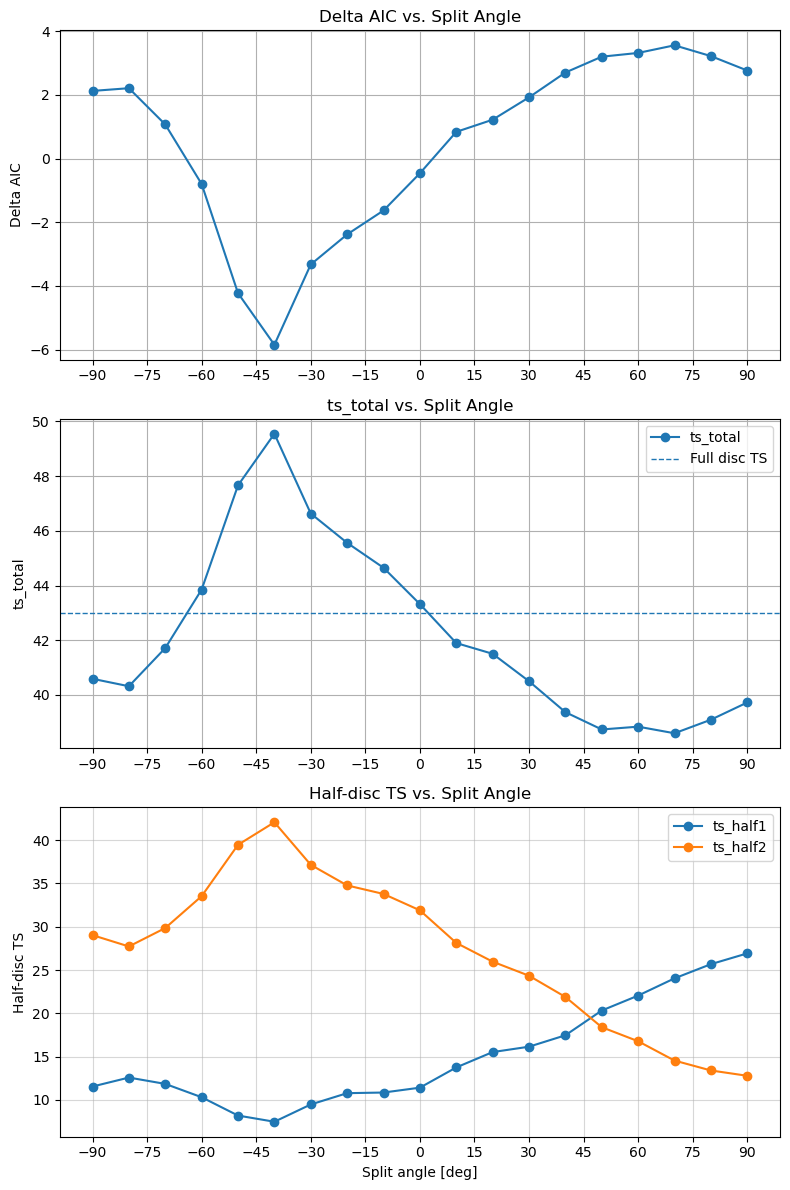

In [16]:
plot_split_angle_metrics("/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/vlad_notebooks/Fermi_7_500GeV/scan_split_angle_results.csv", ts = 43)